In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

## Load dirs

In [10]:
nback_dir = Path(r"..\..\data\2-back\beh+sub\2-back test")
nback_files = list(nback_dir.glob("*.csv"))
print(len(nback_files), "2-back files")

2 2-back files


In [11]:
participants = {}

file_groups = [
    ("nback", nback_files)
]

for key, files in file_groups:
    for f in files:
        match = re.match(r"^(\d+)_", f.name)
        if not match:
            continue

        pid = match.group(1)

        if pid not in participants:
            participants[pid] = {
                "before": None,
                "after": None,
                "nback": None
            }

        participants[pid][key] = f

In [12]:
for pid, files in sorted(participants.items(), key=lambda x: int(x[0])):
    print(f"\n--- Participant {pid} ---")
    print(f"NBACK  : {files['nback']}")


--- Participant 3 ---
NBACK  : ..\..\data\2-back\beh+sub\2-back test\3_untitled_2026-04-27_13h22.42.254.csv

--- Participant 4 ---
NBACK  : ..\..\data\2-back\beh+sub\2-back test\4_untitled_2026-04-28_09h17.26.978.csv


## Subjective sleepiness results

In [13]:
participant_data = {}

for pid, files in participants.items():
    participant_data[pid] = {
        "nback": pd.read_csv(files["nback"])
    }

In [14]:
rows = []

for pid, data in participant_data.items():
    nback_df = data["nback"].copy()

    # Clean RSME column
    nback_df["RSME"] = pd.to_numeric(
        nback_df["RSME_ticks.response"], errors="coerce"
    )

    nback_df = nback_df[nback_df["RSME"].notna()].copy().reset_index(drop=True)

    if len(nback_df) == 0:
        continue

    # Create block index
    nback_df["block"] = np.arange(1, len(nback_df) + 1)

    # Keep target if exists
    if "target" in nback_df.columns:
        nback_df["target"] = nback_df["target"]
    else:
        nback_df["target"] = np.nan

    # Store
    for _, row in nback_df.iterrows():
        rows.append({
            "pid": int(pid),
            "block": row["block"],
            "RSME": row["RSME"]
        })

# Final DataFrame
df_rsme = pd.DataFrame(rows)

print("Participants:", df_rsme["pid"].nunique())
print(df_rsme)

Participants: 2
   pid  block  RSME
0    3      1   5.0
1    3      2   5.0
2    3      3   8.0
3    3      4   8.0
4    4      1   3.0
5    4      2   4.0
6    4      3   3.0
7    4      4   4.0


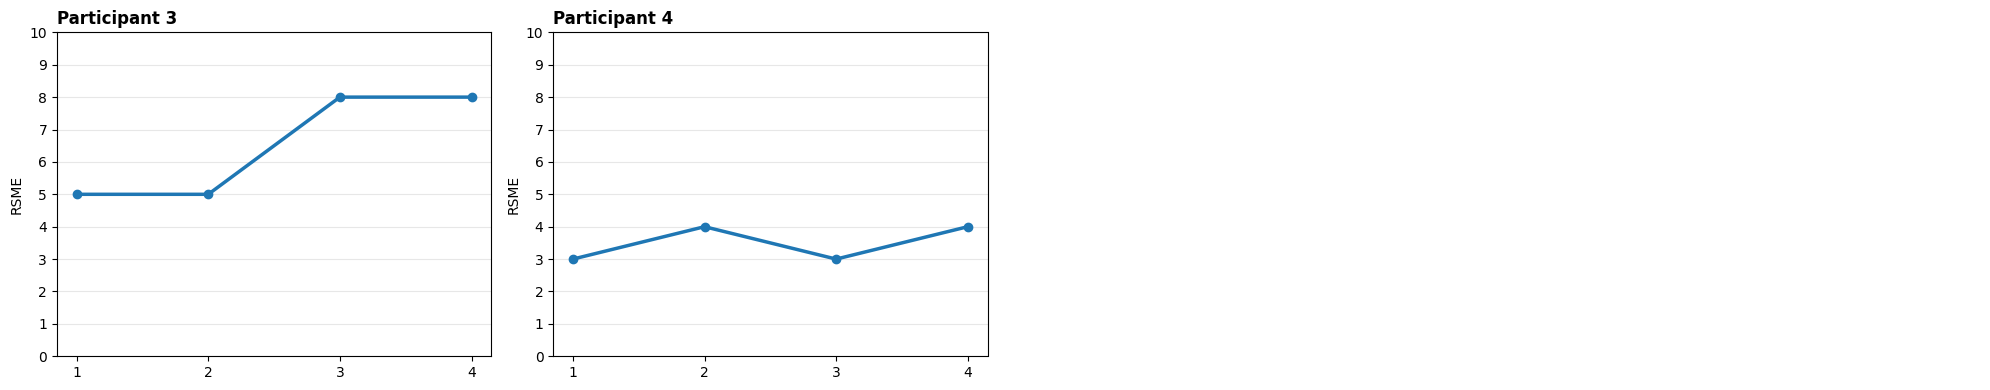

In [15]:
pids = sorted(df_rsme["pid"].unique())
ncols = 4
nrows = int(np.ceil(len(pids) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.array(axes).reshape(-1)

for ax, pid in zip(axes, pids):
    temp = df_rsme[df_rsme["pid"] == pid]

    if temp.empty:
        ax.set_title(f"P{pid} - no data")
        ax.axis("off")
        continue

    ax.plot(temp["block"], temp["RSME"], marker="o", linewidth=2.5)

    ax.set_title(f"Participant {pid}", loc="left", fontweight="bold")
    ax.set_ylabel("RSME")
    ax.set_xticks(temp["block"])
    ax.set_yticks(range(0, 11))
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(pids):]:
    ax.axis("off")

plt.tight_layout()
plt.show()